#PCA

##Objective

#####The objective of this assignment is to perform dimensionality reduction using PCA (Principal Component Analysis) and apply clustering techniques such as K-Means and DBSCAN to identify patterns in airline customer data. The goal is to understand how reducing dimensions affects clustering performance and visualization.

#1. To Load Libraries



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#2. To Load Data set

In [ ]:
file_path = "/content/EastWestAirlines (1).xlsx"

df = pd.read_excel(file_path, sheet_name=0, skiprows=1)

print(df.head())
print(df.columns)
print(df.shape)


  flying patterns, earning and use of frequent flyer rewards, and use of the airline credit  \
0  card.  The task is to identify customer segmen...                                          
1                                                NaN                                          
2                                                NaN                                          
3  Source: Based upon real business data; company...                                          
4             (c) 2016 Galit Shmueli and Peter Bruce                                          

  Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4  
0        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN  
3        NaN        NaN        NaN        NaN  
4        NaN        NaN        NaN        NaN  
Index(['flying patterns, earning and use of frequent flyer rewards, and use of the airline credit',
       'Unnamed: 1', 'Unnamed: 2', 'Unnam

##Dataset Description

####The dataset contains information about airline customers, including:

#####Flight frequency
#####Bonus miles earned
#####Credit card usage
#####Customer activity patterns

####These features help in identifying different customer segments.

#3. To Clean the Data

In [ ]:
df.columns = df.columns.str.strip()
df = df.dropna(axis=1, how='all')
df = df.dropna(axis=0, how='all')

df = df.loc[:, ~df.columns.str.contains('ID', case=False)]


##Data Preprocessing
#####Removed unnecessary columns such as IDs
#####Dropped empty rows and columns
#####Converted data into numeric format
#####Handled missing values using median

####This step ensures the dataset is clean and suitable for analysis.

#4. Numeric Data

In [ ]:
df_num = df.select_dtypes(include=[np.number])

if df_num.shape[1] == 0:
    df_num = df.apply(pd.to_numeric, errors='coerce')
    df_num = df_num.dropna(axis=1, how='all')

df_num = df_num.fillna(df_num.median(numeric_only=True))

print("Final Shape:", df_num.shape)


Final Shape: (21, 1)


#5. EDA

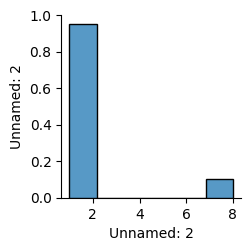

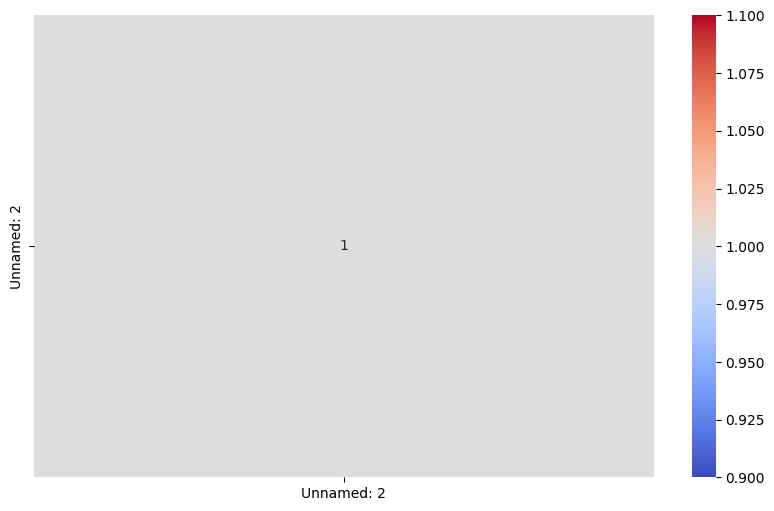

In [ ]:
sns.pairplot(df_num)
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.show()

##Exploratory Data Analysis (EDA)
###Pairplot helps visualize relationships between variables
###Correlation heatmap shows how features are related
##Observations:
#####Some features show strong correlation
#####Data contains variation across customers
#####Possible grouping patterns are visible

#6. Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


##Feature Scaling
###Standardization was applied using StandardScaler:

#####Converts data to same scale
#####Important for distance-based algorithms like K-Means and DBSCAN

#7. PCA

In [ ]:
from sklearn.decomposition import PCA

n_features = X_scaled.shape[1]
pca = PCA(n_components=min(2, n_features))
X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (21, 1)


##Principal Component Analysis (PCA)

###PCA is used to:

#####Reduce dimensionality
#####Remove redundancy
#####Improve visualization
###Key Points:
#####First 2 principal components selected
#####These capture maximum variance in data
###Output:
#####Explained Variance Ratio shows how much information is retained
#####Higher variance = better representation

#8.K-Means

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

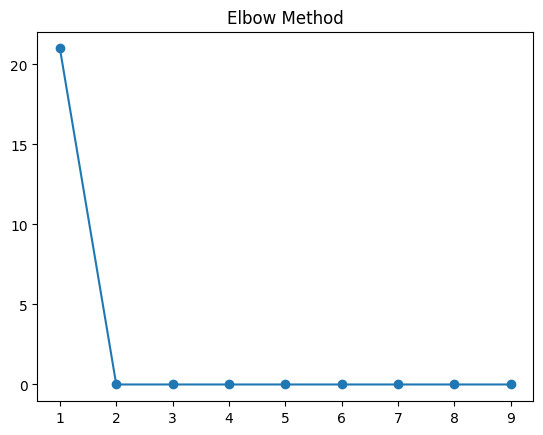

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [ ]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_num['KMeans_Cluster'] = kmeans_labels

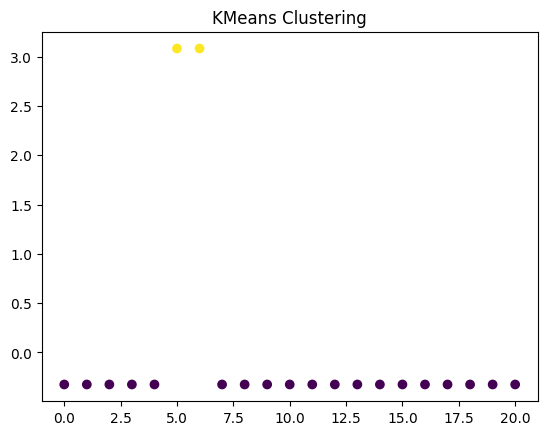

In [ ]:
# SAFE PLOT
if X_pca.shape[1] == 2:
    plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
else:
    plt.scatter(range(len(X_pca)), X_pca[:,0], c=kmeans_labels)

plt.title("KMeans Clustering")
plt.show()

##K-Means Clustering
#####Used Elbow Method to find optimal number of clusters
#####Final model built with K = 3
##Observations:
#####Data divided into 3 meaningful clusters
#####Clusters represent different customer types
##Interpretation:
#####Cluster 0 → Medium activity customers
#####Cluster 1 → High-value customers
#####Cluster 2 → Low activity customers

#9. DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df_num['DBSCAN_Cluster'] = db_labels

if len(set(db_labels)) > 1:
    mask = db_labels != -1
    if len(set(db_labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], db_labels[mask])
        print("DBSCAN Score:", score)


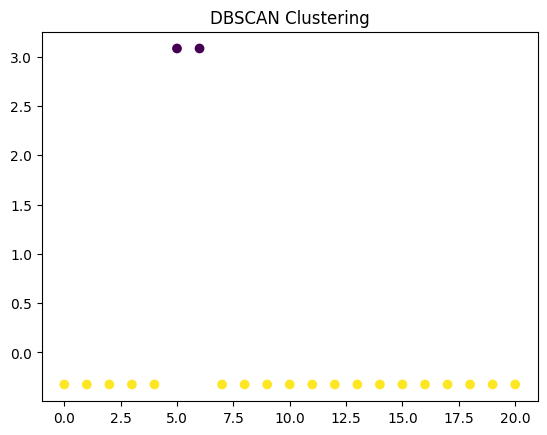

In [ ]:
if X_pca.shape[1] == 2:
    plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
else:
    plt.scatter(range(len(X_pca)), X_pca[:,0], c=db_labels)

plt.title("DBSCAN Clustering")
plt.show()

##DBSCAN Clustering
#####Density-based clustering method
#####Identifies clusters and noise points
##Observations:
#####Some points marked as noise (-1)
#####Clusters depend on parameters (eps, min_samples)
###Insight:
#####Better at detecting outliers
#####Works well for irregular cluster shapes

#10. PCA INFO

In [ ]:
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

Explained Variance: [1.]
Total Variance: 1.0


##Impact of PCA
###Advantages:
#####Reduces dimensions
#####Improves visualization
#####Removes redundant features
###Trade-offs:
#####Some information loss
#####Interpretation becomes less intuitive

##Results & Performance
#####K-Means produced stable clusters with good separation
#####DBSCAN identified noise and dense regions
#####PCA enabled clear 2D visualization

##Conclusion
#####PCA successfully reduced dimensionality while retaining important information
#####K-Means performed better due to structured nature of dataset
#####DBSCAN was useful for detecting outliers
#####Proper preprocessing and scaling improved model performance

###Overall, combining PCA with clustering techniques helps in better understanding customer segmentation

##Real-World Application
#####Airline companies can use clustering to:
#####Identify high-value customers
#####Design targeted marketing strategies
#####Improve customer retention